<a href="https://colab.research.google.com/github/OguzhanB16/Deep-Learning/blob/main/food_101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets
import torchvision.models as models
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import matplotlib.pyplot as plt

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [13]:
!nvidia-smi

Sat Oct  3 16:55:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   73C    P0             32W /   70W |     529MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [14]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop((224, 224)),
    transforms.RandomHorizontalFlip(p= 0.5),
    transforms.RandomRotation(degrees= 15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(size= 256),
    transforms.CenterCrop(size= 224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.Food101(
    root="./data",
    split="train",
    transform=train_transform,
    download=True
)

# Split train_dataset to train_dataset and val_dataset
train_dataset, val_dataset = random_split(train_dataset, [0.85, 0.15])

test_dataset = datasets.Food101(
    root="./data",
    split="test",
    transform= test_transform,
    download=True
)

print("Train:", len(train_dataset))
print("Val", len(val_dataset))
print("Test:", len(test_dataset))

Train: 64388
Val 11362
Test: 25250


In [15]:
train_dataloader = DataLoader(
    dataset= train_dataset,
    batch_size= 32,
    shuffle= True,
    num_workers= 8,
    pin_memory= True
)

val_dataloader = DataLoader(
    dataset= val_dataset,
    batch_size= 32,
    shuffle= True,
    num_workers= 8,
    pin_memory= True
)

test_dataloader = DataLoader(
    dataset= test_dataset,
    batch_size= 32,
    shuffle= False,
    num_workers= 8,
    pin_memory= True
)

In [16]:
# find number of class
class_names = train_dataset.dataset.classes

num_class = len(class_names)

print(num_class)
print(f"First 5 class names: {class_names[:5]}")

# Create pre-trained model with default parameters

weight = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights= weight)

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(in_features= num_features, out_features= num_class)

model.to(device= device)

101
First 5 class names: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [17]:
criterion = nn.CrossEntropyLoss()

layer4_params = list(model.layer4.parameters())

layer4_ids = {id(param) for param in layer4_params}

other_params = [
    param
    for param in model.parameters()
    if param.requires_grad and id(param) not in layer4_ids
]

optimizer = optim.Adam([
    {'params': layer4_params, 'lr': 1e-5},
    {'params': other_params, 'lr': 1e-3}
])

scheduler = lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

In [18]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            print(f"⚠️ EarlyStopping Sayacı: {self.counter} / {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

In [19]:
epochs = 200
accumulation_steps = 2

scaler = torch.amp.GradScaler("cuda")
best_val_loss = float('inf')
early_stopping = EarlyStopping(patience= 10, min_delta= 0.001)

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

for epoch in range(epochs):

    model.train()
    optimizer.zero_grad(set_to_none=True)

    total_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)

        with torch.autocast(device_type=device, dtype=torch.float16):
            y_pred = model(X)
            loss = criterion(y_pred, y)

        total_train_loss += loss.item()
        _, predicted = torch.max(y_pred.data, 1)
        total_train += y.size(0)
        correct_train += (predicted == y).sum().item()

        scaler.scale(loss / accumulation_steps).backward()

        if (i + 1) % accumulation_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

    if len(train_dataloader) % accumulation_steps != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

    model.eval()
    total_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.inference_mode():
        for X_val, y_val in val_dataloader:
            X_val, y_val = X_val.to(device), y_val.to(device)

            with torch.autocast(device_type=device, dtype=torch.float16):
                y_pred_val = model(X_val)
                val_loss = criterion(y_pred_val, y_val)

            total_val_loss += val_loss.item()
            _, predicted_val = torch.max(y_pred_val.data, 1)
            total_val += y_val.size(0)
            correct_val += (predicted_val == y_val).sum().item()

    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_val_loss = total_val_loss / len(val_dataloader)

    train_acc = 100 * correct_train / total_train
    val_acc = 100 * correct_val / total_val

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if avg_val_loss < best_val_loss:
        print(f"🌟 New best model! (Val Loss decreased: {best_val_loss:.4f} -> {avg_val_loss:.4f}). Saving...")
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_food101_model.pth")

    early_stopping(avg_val_loss)

    if early_stopping.early_stop:
        print(f"🛑 Eğitim {epoch+1}. Epoch'ta erken durduruldu! Model daha fazla öğrenemiyor.")
        break

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} - Train Acc: %{train_acc:.2f} | "
        f"Val Loss: {avg_val_loss:.4f} - Val Acc: %{val_acc:.2f}"
    )

🌟 New best model! (Val Loss decreased: inf -> 2.3863). Saving...
Epoch [1/200] | Train Loss: 2.9578 - Train Acc: %36.19 | Val Loss: 2.3863 - Val Acc: %44.37
🌟 New best model! (Val Loss decreased: 2.3863 -> 2.1113). Saving...
Epoch [2/200] | Train Loss: 2.2392 - Train Acc: %47.60 | Val Loss: 2.1113 - Val Acc: %50.14
🌟 New best model! (Val Loss decreased: 2.1113 -> 2.0561). Saving...
Epoch [3/200] | Train Loss: 2.0605 - Train Acc: %50.73 | Val Loss: 2.0561 - Val Acc: %51.15
🌟 New best model! (Val Loss decreased: 2.0561 -> 1.9655). Saving...
Epoch [4/200] | Train Loss: 1.9497 - Train Acc: %53.07 | Val Loss: 1.9655 - Val Acc: %52.16
⚠️ EarlyStopping Sayacı: 1 / 10
Epoch [5/200] | Train Loss: 1.8929 - Train Acc: %54.09 | Val Loss: 1.9829 - Val Acc: %51.80
🌟 New best model! (Val Loss decreased: 1.9655 -> 1.9310). Saving...
Epoch [6/200] | Train Loss: 1.8520 - Train Acc: %54.70 | Val Loss: 1.9310 - Val Acc: %53.53
🌟 New best model! (Val Loss decreased: 1.9310 -> 1.8924). Saving...
Epoch [7/20

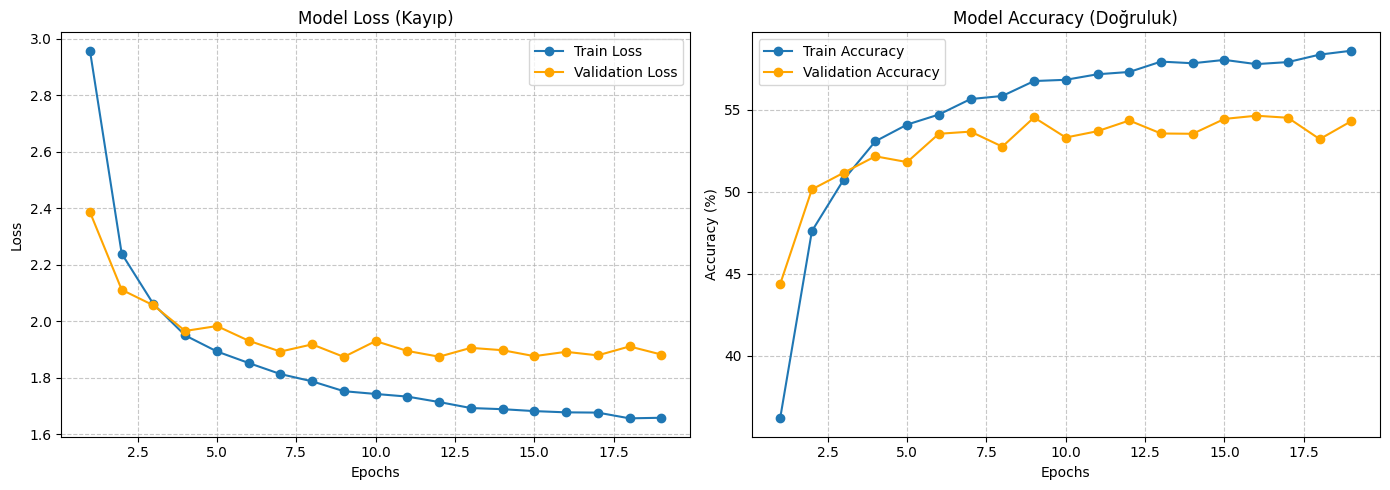

In [20]:
def plot_training_history(history):
    epochs_range = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14, 5))

    # --- 1. LOSS GRAFİĞİ ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
    plt.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='o', color='orange')
    plt.title('Model Loss (Kayıp)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # --- 2. ACCURACY GRAFİĞİ ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Train Accuracy', marker='o')
    plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy', marker='o', color='orange')
    plt.title('Model Accuracy (Doğruluk)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

plot_training_history(history)